In [1]:
import os
# Force CPU backend on Apple Silicon to avoid Metal issues
os.environ['JAX_PLATFORMS'] = 'cpu'

# Disable LaTeX rendering in matplotlib
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "sans-serif"

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
from collections import defaultdict

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import PatchForagingDDM_JAX, create_prior

In [17]:
simulator = PatchForagingDDM_JAX()

drift_rate = -.15
reward_bump = -0.3
failure_bump = .6
noise_std = 0.1

theta = jnp.array([drift_rate, reward_bump, failure_bump, noise_std])
max_sites_per_window = 1000

In [18]:
def extract_state_transitions(window_data):
    """
    Extract (state, outcome) pairs from window_data.
    
    Returns list of tuples: [(n_rewards, n_failures, left_patch), ...]
    where left_patch is True if animal left, False if stayed
    """
    transitions = []
    
    current_rewards = 0
    current_failures = 0
    prev_patch_time = 0
    
    for site_idx in range(len(window_data)):
        patch_time, reward, stopped = window_data[site_idx]
        
        # Skip padding (all zeros after simulation ends)
        if patch_time == 0 and site_idx > 0:
            break
        
        # Detect patch exit: patch_time reset (got smaller)
        left_patch = (patch_time < prev_patch_time) if site_idx > 0 else False
        
        if left_patch:
            # Record the state BEFORE leaving
            # (use previous site's state)
            transitions.append((current_rewards, current_failures, True))
            
            # Reset state for new patch
            current_rewards = 0
            current_failures = 0
        else:
            # Animal stayed, record this state
            if site_idx > 0:  # Don't record first site (entering patch)
                transitions.append((current_rewards, current_failures, False))
            
            # Update state based on this site's outcome
            if reward > 0:
                current_rewards += 1
                current_failures = 0  # Reset failures after reward
            else:
                current_failures += 1
        
        prev_patch_time = patch_time
    
    return transitions

In [19]:
n_simulations = 1000
rng_key = random.PRNGKey(42)

state_counts = defaultdict(lambda: {'left': 0, 'stayed': 0})

for i in range(n_simulations):
    if i % (n_simulations // 10) == 0:
        print(f"Simulation {i}/{n_simulations}")
    
    rng_key, subkey = random.split(rng_key)
    window_data, _ = simulator.simulate_one_window(theta, subkey)
    
    # Extract transitions from this simulation
    transitions = extract_state_transitions(window_data)
    
    # Accumulate counts
    for n_rewards, n_failures, left in transitions:
        state = (n_rewards, n_failures)
        if left:
            state_counts[state]['left'] += 1
        else:
            state_counts[state]['stayed'] += 1

print(f"\nCollected data from {len(state_counts)} unique states")

Simulation 0/1000
Simulation 100/1000
Simulation 200/1000
Simulation 300/1000
Simulation 400/1000
Simulation 500/1000
Simulation 600/1000
Simulation 700/1000
Simulation 800/1000
Simulation 900/1000

Collected data from 333 unique states


In [20]:
max_rewards = 20
max_failures = 15
min_visits = 200

prob_leave = np.full((max_rewards, max_failures), np.nan)

for rewards in range(max_rewards):
    for failures in range(max_failures):
        state = (rewards, failures)
        if state in state_counts:
            counts = state_counts[state]
            total = counts['left'] + counts['stayed']
            if total > min_visits:  # Only plot if visited more than 5 times
                prob_leave[rewards, failures] = counts['left'] / total

print(f"Non-NaN cells: {np.sum(~np.isnan(prob_leave))}")

Non-NaN cells: 136


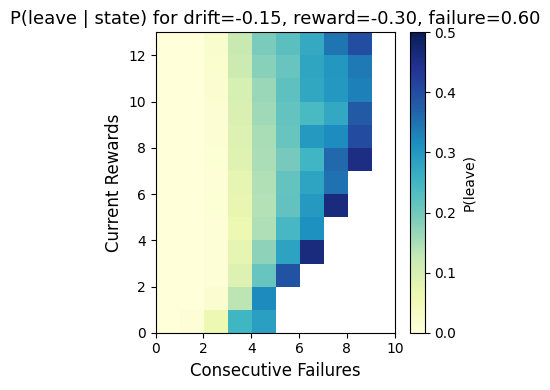

In [21]:
fig, ax = plt.subplots(figsize=(4, 4))

im = ax.imshow(prob_leave, origin='lower', aspect='auto', 
               cmap='YlGnBu', vmin=0, vmax=0.5,
               extent=[0, max_failures, 0, max_rewards])

ax.set_xlabel('Consecutive Failures', fontsize=12)
ax.set_ylabel('Current Rewards', fontsize=12)
ax.set_ylim(0, 13)
ax.set_xlim(0, 10)
ax.set_title(f'P(leave | state) for drift={drift_rate:.2f}, reward={reward_bump:.2f}, failure={failure_bump:.2f}', 
             fontsize=13)

cbar = plt.colorbar(im, ax=ax, label='P(leave)')

plt.tight_layout()
plt.show()